In [2]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM, LeCroyScope
from Equipments.MCBOX import generate_test_voltages

from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [3]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [3]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB1::0x1313::0x807B::241023118::0::INSTR')


In [4]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [4]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


In [6]:
bias_channel = 11

In [30]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0.14, bipolar = True, display = True) # changed from 2.8 V

Channel 11 has been set to 0.14 V.


In [19]:
agilent = Agilent.Agilent('TCPIP0::169.254.110.10::inst0::INSTR',power_limit = 0, freq_limit = 40e9)

Agilent Technologies, N5183A, MY47420242, A.01.43



In [4]:

pm = ThorlabsPM.ThorlabsPM('USB0::0x1313::0x807B::241023118::0::INSTR')

Thorlabs,PM16-130,241023118,1.6.0



In [42]:
pm.readout(wavelength = 1064)

0.006156154

In [23]:
pm.readout(wavelength = 1064, average = 50)

0.0020372258

## agilent.set_frequency(frequency = 0.7e9)

## 700MHz

In [ ]:
agilent.set_frequency(frequency = 0.7e9)

output_power = []
RF_power_list = np.linspace(-30, 0, 31) # [dBm]
bias_list = np.linspace(-4,7,41) # [V]
bias_channel = 11  # added this
print(RF_power_list)
print(bias_list)

agilent.set_power(RF_power_list[0])
agilent.start_output()

for RF_power in RF_power_list:
    print(f"Now checking {RF_power}dBm")
    agilent.set_power(RF_power)
    time.sleep(1)
    sub_output_power = []
    for bias in bias_list:
        mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
        time.sleep(2e-3)
        power = pm.readout(wavelength = 1064,average=50) # changed from 780 nm
        sub_output_power.append(power)
    print(sub_output_power)
    output_power.append(sub_output_power)   
agilent.stop_output()
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

In [ ]:
ps.Plot3D(x = RF_power_list+30, y = bias_list, Z = np.array(output_power),
          xlabel = "RF power after Amp (dBm) @ 700MHz", ylabel = "DC bias (V)", zlabel = "Output Power (W)",transpose=True)  

## 38GHz

RF_list_top = np.linspace(-14.5,-5,50)
RF_list_bot = np.linspace(-35,-15,20)
RF_power_list = np.concatenate((RF_list_bot,RF_list_top), axis=0)
print(RF_power_list)

In [35]:
angle = 95.0 # [deg]
#power = 1.6 # [mW]

output_power = []
#RF_power_list = np.linspace(-20,-3,39) # [dBm]
#RF_list_top = np.linspace(-14.5,-5,50)
#RF_list_bot = np.linspace(-35,-15,20)
#RF_power_list = np.concatenate((RF_list_bot,RF_list_top), axis=0)

#bias_list = np.linspace(-10,10,41) # [V]

RF_power_list = np.arange(-20,-2.6,0.4)
bias_list = np.arange(-10,10.25,0.25)

bias_channel = 11  # added this
print(RF_power_list)
print(bias_list)

agilent.set_frequency(frequency = 38.0e9)  # changed from 10 GHz
agilent.set_power(RF_power_list[0])
agilent.start_output()

for RF_power in RF_power_list:
    print(f"Now checking {RF_power} dBm")
    agilent.set_power(RF_power)
    time.sleep(0.1)
    sub_output_power = []
    for bias in bias_list:
        mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
        time.sleep(2e-3)
        power = pm.readout(wavelength = 1064, average = 50) # changed from 780 nm
        sub_output_power.append(power)
    print(sub_output_power)
    output_power.append(sub_output_power)   
agilent.stop_output()
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

[-20.  -19.6 -19.2 -18.8 -18.4 -18.  -17.6 -17.2 -16.8 -16.4 -16.  -15.6
 -15.2 -14.8 -14.4 -14.  -13.6 -13.2 -12.8 -12.4 -12.  -11.6 -11.2 -10.8
 -10.4 -10.   -9.6  -9.2  -8.8  -8.4  -8.   -7.6  -7.2  -6.8  -6.4  -6.
  -5.6  -5.2  -4.8  -4.4  -4.   -3.6  -3.2  -2.8]
[-10.    -9.75  -9.5   -9.25  -9.    -8.75  -8.5   -8.25  -8.    -7.75
  -7.5   -7.25  -7.    -6.75  -6.5   -6.25  -6.    -5.75  -5.5   -5.25
  -5.    -4.75  -4.5   -4.25  -4.    -3.75  -3.5   -3.25  -3.    -2.75
  -2.5   -2.25  -2.    -1.75  -1.5   -1.25  -1.    -0.75  -0.5   -0.25
   0.     0.25   0.5    0.75   1.     1.25   1.5    1.75   2.     2.25
   2.5    2.75   3.     3.25   3.5    3.75   4.     4.25   4.5    4.75
   5.     5.25   5.5    5.75   6.     6.25   6.5    6.75   7.     7.25
   7.5    7.75   8.     8.25   8.5    8.75   9.     9.25   9.5    9.75
  10.  ]
Now checking -20.0 dBm
[0.0029991372, 0.0019610382, 0.0027376122, 0.0038357726, 0.0043201488, 0.0038862971, 0.0027346557, 0.001444675, 0.00059696799, 0.000

In [ ]:
RF_power_list += 30  # accounts for the amplifier
RF_power_list = (1/1000)*10**(RF_power_list/10)  # convert from dBm to W

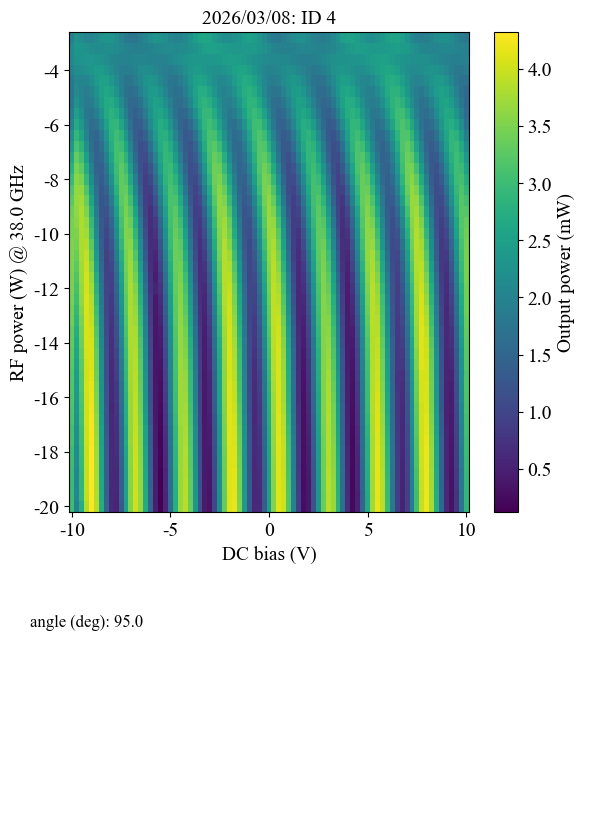

In [36]:
ps.Plot3D(x = RF_power_list, y = bias_list, Z = np.array(output_power)*1e+3,
          xlabel = "RF power (W) @ 38.0 GHz", ylabel = "DC bias (V)", zlabel = "Output power (mW)", transpose = True, notes = {"angle (deg)": angle})  

In [66]:
pm.close()

In [38]:
agilent.close()

In [39]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

Channel 11 has been set to 0 V.


In [67]:
rm.list_opened_resources()

[]

In [41]:
rm.close()

## Check the polarization

In [21]:
def func(x,a,b,c,d):
    return a*np.sin(b*x+c)+d

In [35]:
bias_list = np.linspace(-10,10,351) # [V]
transmission = []

for bias in bias_list:
    print(f"\rNow at {bias:.2f} V", end = "", flush = True)
    mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
    power = pm.readout(wavelength = 1064, average = 50)
    transmission.append(power)

Now at 10.00 VV

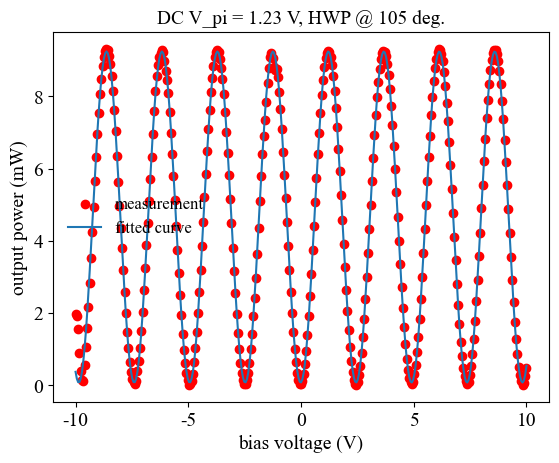

In [36]:
initial_guess = [0.002,2.5,0,0]

popt1, pcov1 = curve_fit(
            func, bias_list, transmission, p0 = initial_guess, maxfev = 10000000, method ='lm')

# popt1, pcov1 = curve_fit(
#             func, bias_list, transmission,maxfev=10000000,method='lm'
#         )

plt.figure()
plt.scatter(bias_list,np.array(transmission)*1e+03, c = "r", label = "measurement")
plt.plot(bias_list,func(bias_list,*popt1)*1e+03, label = "fitted curve")
plt.xlabel('bias voltage (V)')
plt.ylabel("output power (mW)")
plt.title(f"DC V_pi = {round(np.pi/popt1[1],3)} V, HWP @ 105 deg.")
plt.legend()
plt.show()

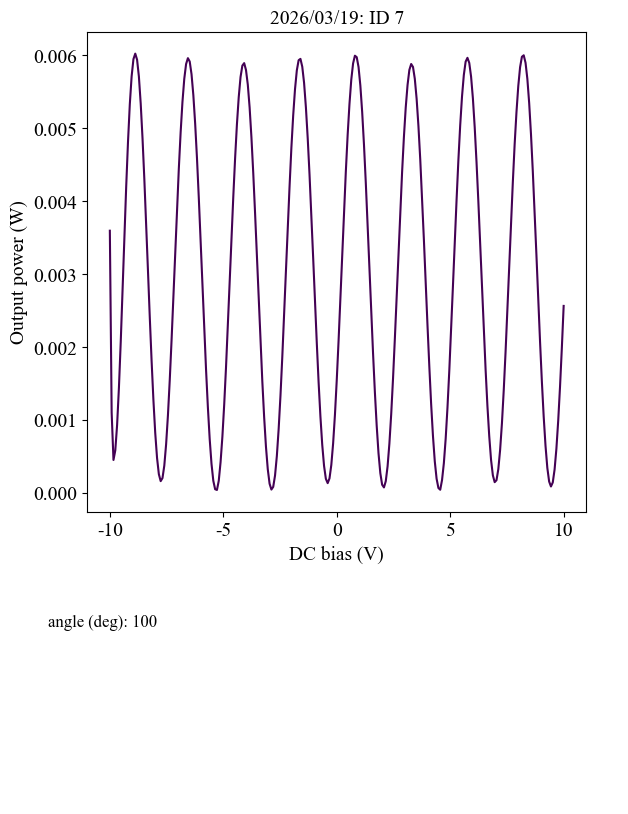

In [65]:
ps.Plot2D(x = bias_list, y = None, Z = transmission, xlabel = 'DC bias (V)', ylabel = 'Y', zlabel = 'Output power (W)',notes = {"angle (deg)": 100})

In [34]:
10*np.log10(max(transmission)/min(transmission))

22.456400269902662

In [ ]:
print(len(bias_list))
print(len(transmission))

## test the degrade for RF

In [ ]:
plt.scatter(voltage,transimission_intensity)

In [ ]:
transimission_intensity = np.array([5.8,])
voltage = np.array([-4,-3.5,-3,-2.5,-2,-1.5,-1,-0.5,0,])

In [ ]:
plt.scatter(voltage,transimission_intensity)

In [ ]:
def func(x,a,b,c):
    return a*np.sin(b*x)+c

popt1, pcov1 = curve_fit(
            func, voltage, transimission_intensity,maxfev=100000,
        )

In [ ]:
popt1

In [ ]:
plt.plot(voltage, func(voltage,*popt1))

In [6]:
pulse_arrangement = [
                     ["F", 20e-6, 0, 5],                   # DEI switch
                    ]
T = 1000e-6

bnc575.clock_set(period = T, mode = "CONTINUOUS")
bnc575.pulse_sequence_setup(pulse_arrangement)

------------------------------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
------------------------------------------------------------
[['F', 2e-05, 0, 5]]
------------------------------------------------------------
The channel F is set to:
Width: 2.0000e-05s
Delay: 0.0000e+00s
Synchronize to: T0
Out: 5.00

Output timers:
HGFEDCBA
00100000
------------------------------------------------------------


[['F', 2e-05, 0, 5]]

In [7]:
bnc575.start_pulses()

# stability test

In [3]:
from Equipments import ThorlabsPM

ModuleNotFoundError: No module named 'thorlabs_tsi_sdk'

# Stability test

In [5]:
powers = []
for i in range(1000):
    power = pm.readout(wavelength = 1064, average = 50)
    time.sleep(1)
    powers.append(power)
    

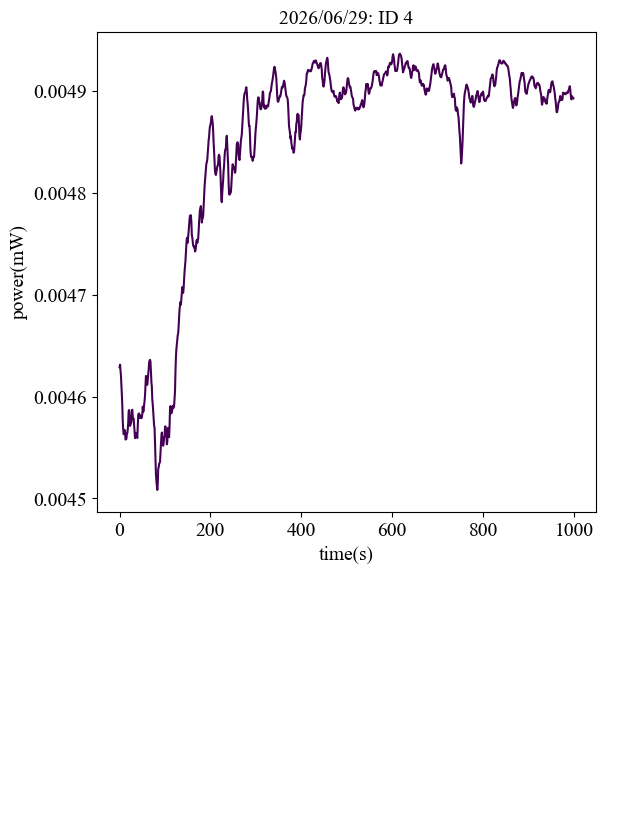

In [8]:
ps.Plot2D(x = np.arange(1000), y = None, Z = powers,
          xlabel = "time(s)", zlabel = "power(mW)")